# EUR/USD Model Notebook
This notebook is a runnable version of `eurusd_model.py`. Run cells in order.

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

TICKERS = {
    "eurusd": "EURUSD=X",
    "vix": "^VIX",
    "dxy": "DX-Y.NYB",
    "us10y": "^TNX",
    "us2y": "^IRX",
    "gold": "GC=F",
}

BASE_FEATURES = ["vix", "dxy", "us10y", "us2y", "gold"]
FEATURE_COLUMNS = BASE_FEATURES + [
    "rate_spread",
    "vix_chg_5d",
    "dxy_chg_5d",
    "vix_lag2",
    "dxy_lag2",
    "spread_lag2",
    "vix_x_spread",
]
TARGET_COLUMN = "eurusd_fwd_level"
TARGET_HORIZON_DAYS = 5

@dataclass
class ModelArtifacts:
    model_name: str
    model: object
    metrics: Dict[str, float]
    X: pd.DataFrame
    y: pd.Series
    data_source: str

In [ ]:
def generate_fallback_data(start: str = "2012-01-01", periods: int = 2400) -> pd.DataFrame:
    rng = np.random.default_rng(42)
    dates = pd.date_range(start=start, periods=periods, freq="B")

    vix = 18 + rng.normal(0, 1.4, periods)
    dxy = 101 + rng.normal(0, 1.1, periods)
    us10y = 2.3 + rng.normal(0, 0.15, periods)
    us2y = 2.0 + rng.normal(0, 0.14, periods)
    gold = 1750 + rng.normal(0, 35, periods)

    eurusd = np.zeros(periods)
    eurusd[0] = 1.12
    for i in range(1, periods):
        structural = (
            1.11
            - 0.0013 * (vix[i] - 18)
            - 0.0024 * (dxy[i] - 101)
            + 0.0100 * (us10y[i] - us2y[i])
            + 0.00003 * (gold[i] - 1750)
        )
        eurusd[i] = 0.7 * eurusd[i - 1] + 0.3 * structural + rng.normal(0, 0.0015)

    return pd.DataFrame(
        {
            "eurusd": eurusd,
            "vix": vix,
            "dxy": dxy,
            "us10y": us10y,
            "us2y": us2y,
            "gold": gold,
        },
        index=dates,
    )

def fetch_market_data(start: str = "2012-01-01") -> Tuple[pd.DataFrame, str]:
    symbols = list(TICKERS.values())
    try:
        raw = yf.download(symbols, start=start, progress=False)
        if raw.empty:
            raise RuntimeError("No market data returned from Yahoo Finance.")

        if isinstance(raw.columns, pd.MultiIndex):
            close = raw["Close"].copy()
        else:
            close = raw.copy()

        reverse_map = {v: k for k, v in TICKERS.items()}
        close = close.rename(columns=reverse_map)
        missing = [k for k in TICKERS if k not in close.columns]
        if missing:
            raise RuntimeError(f"Missing downloaded series: {missing}")

        return close[list(TICKERS.keys())].dropna(how="all"), "yahoo_finance"
    except Exception as exc:
        raise RuntimeError("Yahoo Finance download failed; synthetic fallback disabled.") from exc

def build_feature_frame(close: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    data = close.copy()
    data["rate_spread"] = data["us10y"] - data["us2y"]
    data["vix_chg_5d"] = data["vix"].pct_change(5, fill_method=None)
    data["dxy_chg_5d"] = data["dxy"].pct_change(5, fill_method=None)
    data["vix_lag2"] = data["vix"].shift(2)
    data["dxy_lag2"] = data["dxy"].shift(2)
    data["spread_lag2"] = data["rate_spread"].shift(2)
    data["vix_x_spread"] = data["vix"] * data["rate_spread"]
    data[TARGET_COLUMN] = data["eurusd"].shift(-TARGET_HORIZON_DAYS)

    # Use only information available at t to predict return at t+1
    data[FEATURE_COLUMNS] = data[FEATURE_COLUMNS].shift(1)

    modeled = data.dropna().copy()
    X = modeled[FEATURE_COLUMNS]
    y = modeled[TARGET_COLUMN]
    return X, y

In [18]:
def time_series_cv_score(model, X: pd.DataFrame, y: pd.Series, n_splits: int = 5) -> Dict[str, float]:
    splitter = TimeSeriesSplit(n_splits=n_splits)
    fold_r2 = []
    fold_rmse = []

    for train_idx, test_idx in splitter.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        fold_r2.append(r2_score(y_test, preds))
        fold_rmse.append(float(np.sqrt(mean_squared_error(y_test, preds))))

    return {
        "r2_mean": float(np.mean(fold_r2)),
        "rmse_mean": float(np.mean(fold_rmse)),
        "r2_std": float(np.std(fold_r2)),
        "rmse_std": float(np.std(fold_rmse)),
    }

def train_best_model(X: pd.DataFrame, y: pd.Series) -> ModelArtifacts:
    candidates = {}

    for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
        name = f"ridge_scaled_a{alpha:g}"
        candidates[name] = make_pipeline(StandardScaler(), Ridge(alpha=alpha))

    rf_grid = [
        (400, 4, 8),
        (500, 6, 8),
        (600, 8, 12),
    ]
    for n_estimators, max_depth, min_leaf in rf_grid:
        name = f"rf_n{n_estimators}_d{max_depth}_l{min_leaf}"
        candidates[name] = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_leaf,
            random_state=42,
            n_jobs=-1,
        )

    scored = []
    for name, model in candidates.items():
        metrics = time_series_cv_score(model, X, y, n_splits=5)
        scored.append((name, model, metrics))

    scored.sort(key=lambda item: (item[2]["r2_mean"], -item[2]["rmse_mean"]), reverse=True)
    best_name, best_model, best_metrics = scored[0]
    best_model.fit(X, y)

    return ModelArtifacts(
        model_name=best_name,
        model=best_model,
        metrics=best_metrics,
        X=X,
        y=y,
        data_source="unknown",
    )

_MIN_TRAINING_ROWS = 100

def train_pipeline(start: str = "2012-01-01") -> ModelArtifacts:
    close, source = fetch_market_data(start=start)
    if source != "yahoo_finance":
        raise RuntimeError("Only real Yahoo Finance data is allowed for training.")

    X, y = build_feature_frame(close)
    if len(X) < _MIN_TRAINING_ROWS:
        raise RuntimeError(f"Insufficient rows for training: {len(X)} < {_MIN_TRAINING_ROWS}")

    artifacts = train_best_model(X, y)
    artifacts.data_source = source
    return artifacts

def scenario_prediction(model: object, base_features: pd.Series, feature_shocks: Dict[str, float]) -> float:
    scenario = base_features.copy()
    for feature, pct in feature_shocks.items():
        if feature not in scenario.index:
            continue
        scenario[feature] = scenario[feature] * (1 + pct / 100.0)

    return float(model.predict(pd.DataFrame([scenario]))[0])

In [ ]:
START_DATE = "2012-01-01"

artifacts = train_pipeline(start=START_DATE)
latest_x = artifacts.X.iloc[-1]
pred_next_level = float(artifacts.model.predict(pd.DataFrame([latest_x]))[0])

close_latest, _ = fetch_market_data(start=START_DATE)
latest_spot = float(close_latest["eurusd"].dropna().iloc[-1])

print(f"Data source: {artifacts.data_source}")
print(f"Model selected: {artifacts.model_name}")
print(f"Target horizon (days): {TARGET_HORIZON_DAYS}")
print(
    "Time-series CV metrics: "
    f"R2={artifacts.metrics['r2_mean']:.4f} +/- {artifacts.metrics['r2_std']:.4f}, "
    f"RMSE={artifacts.metrics['rmse_mean']:.6f} +/- {artifacts.metrics['rmse_std']:.6f}"
)
print(f"Latest observed forward-level target: {artifacts.y.iloc[-1]:.6f}")
print(f"Predicted EURUSD level at t+{TARGET_HORIZON_DAYS} days: {pred_next_level:.6f}")
print(f"Latest spot EURUSD: {latest_spot:.6f}")
print(f"Predicted spot change: {pred_next_level - latest_spot:+.6f}")

Data source: yahoo_finance
Model selected: rf_n400_d4_l8
Target horizon (days): 5
Time-series CV metrics: R2=-0.1697 +/- 0.1481, RMSE=0.011499 +/- 0.001741
Latest observed forward-return target: -0.000639
Predicted forward EURUSD return: 0.000524
Latest spot EURUSD: 1.161791
Implied spot at t+5 days: 1.162400


## CV Diagnostics: Target vs Predictions

This section computes out-of-fold predictions with time-series cross-validation for each candidate model.

It shows:
- Per-fold metrics (R2 and RMSE)
- Average metrics by model
- Target vs prediction over time (out-of-fold)
- Fold-level metric charts

Per-fold metrics (R2 and RMSE), including naive baseline:


,model,fold,n_train,n_test,r2,rmse
0,ridge_scaled,1,553.0,551,-6.230006,0.035456
1,ridge_scaled,2,1104.0,551,-5.443171,0.024578
2,ridge_scaled,3,1655.0,551,-0.082041,0.009900
3,ridge_scaled,4,2206.0,551,-0.030248,0.011623
4,ridge_scaled,5,2757.0,551,-0.004673,0.009437
5,random_forest,1,553.0,551,-0.320475,0.015152
6,random_forest,2,1104.0,551,-0.523727,0.011952
7,random_forest,3,1655.0,551,-0.301394,0.010857
8,random_forest,4,2206.0,551,-0.185814,0.012469
9,random_forest,5,2757.0,551,0.019361,0.009323



Average metrics by model:


,model,r2_mean,r2_std,rmse_mean,rmse_std
0,naive_zero_return,-0.003724,0.006628,0.010674,0.001683
1,random_forest,-0.262410,0.199023,0.011951,0.002158
2,ridge_scaled,-2.358028,3.187761,0.018199,0.011482


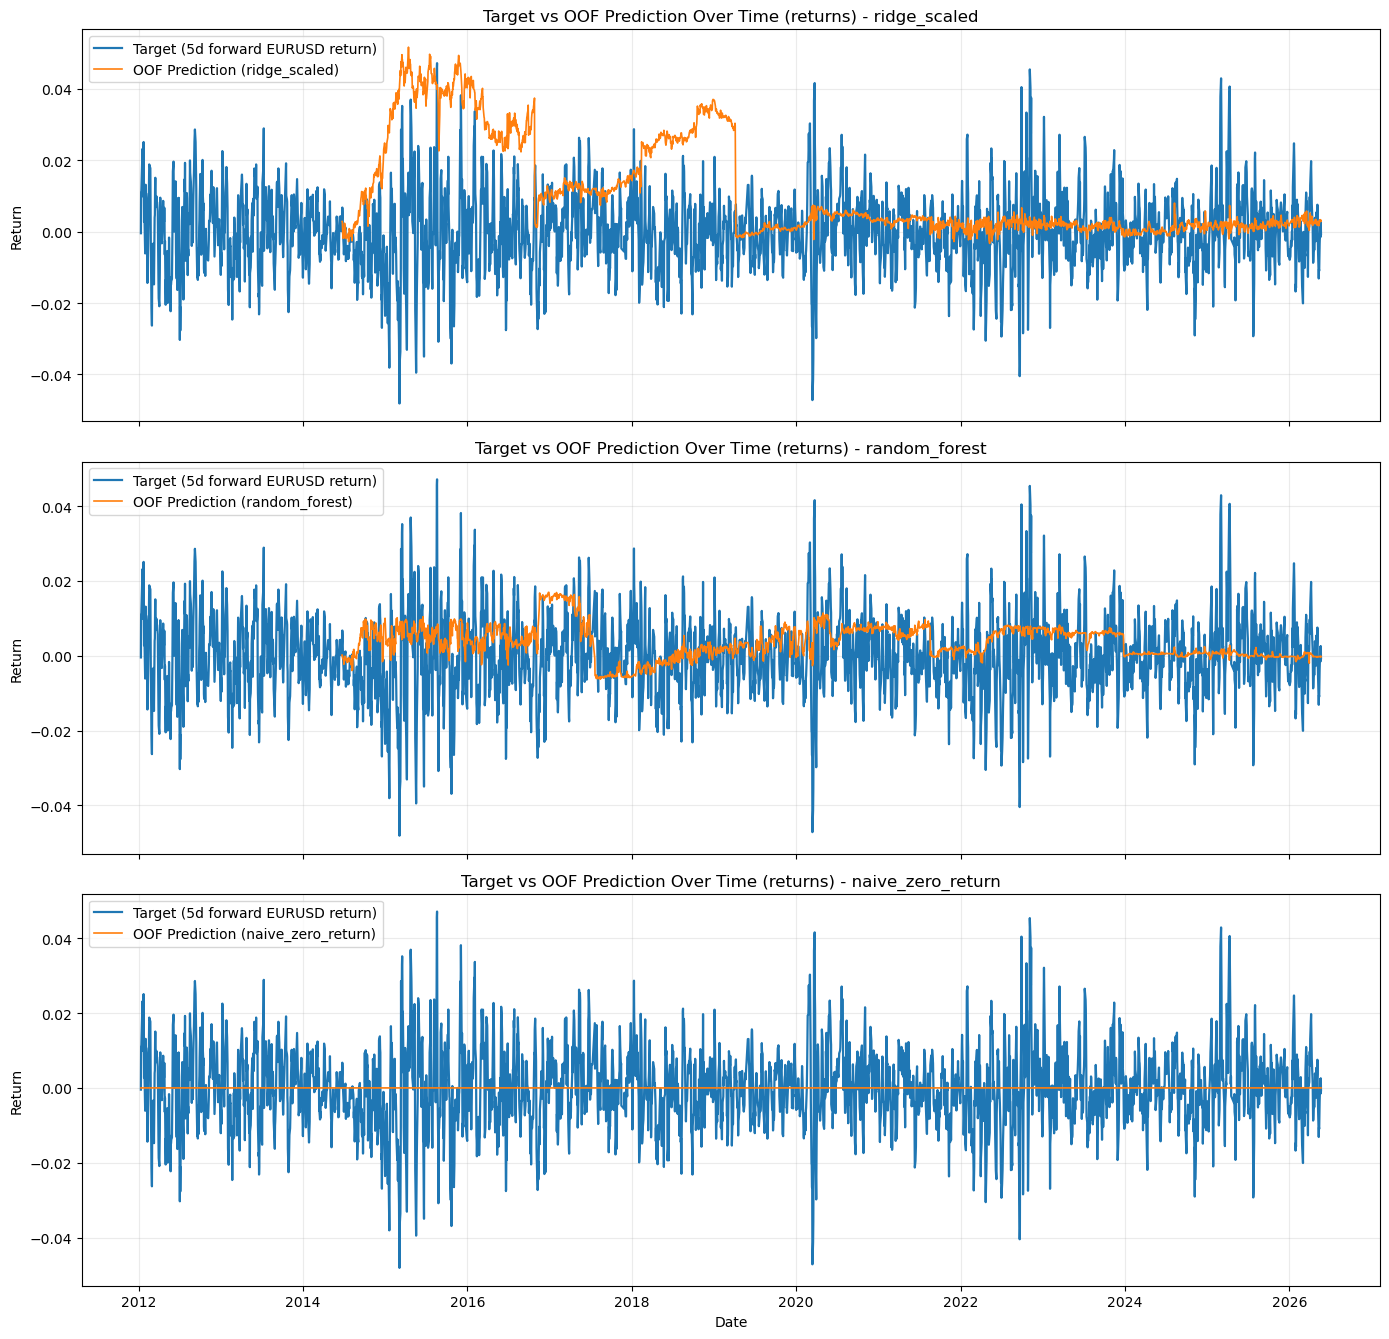

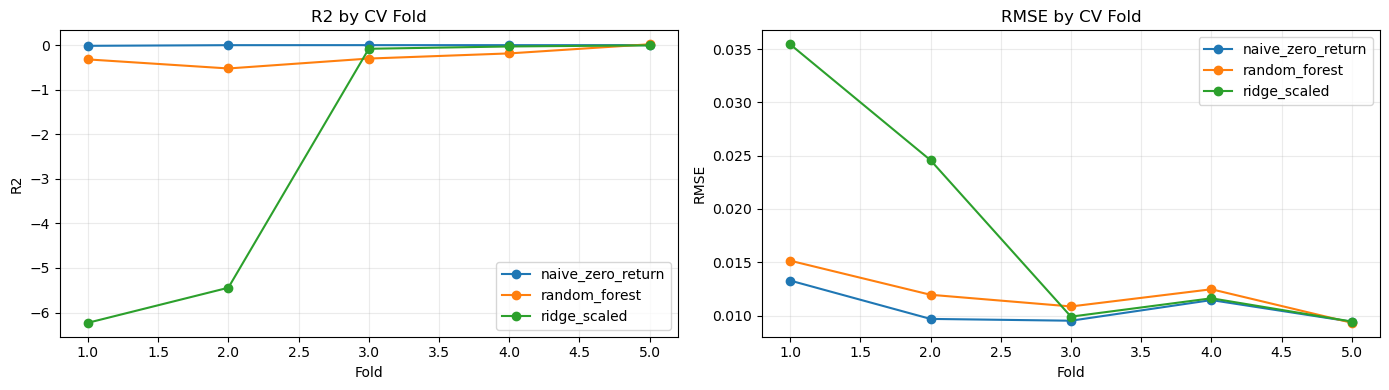

In [ ]:
from sklearn.base import clone
import matplotlib.pyplot as plt


def cv_diagnostics(models: dict, X: pd.DataFrame, y: pd.Series, n_splits: int = 5):
    splitter = TimeSeriesSplit(n_splits=n_splits)

    fold_rows = []
    oof_by_model = {}

    for model_name, model_template in models.items():
        oof_pred = pd.Series(index=y.index, dtype=float)

        for fold, (train_idx, test_idx) in enumerate(splitter.split(X), start=1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model = clone(model_template)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            oof_pred.iloc[test_idx] = preds

            fold_rows.append(
                {
                    "model": model_name,
                    "fold": fold,
                    "n_train": len(train_idx),
                    "n_test": len(test_idx),
                    "r2": r2_score(y_test, preds),
                    "rmse": float(np.sqrt(mean_squared_error(y_test, preds))),
                }
            )

        oof_by_model[model_name] = oof_pred

    # Naive baseline for forward level: persistence from t (mapped as y shifted by horizon rows)
    baseline_pred = y.shift(TARGET_HORIZON_DAYS)
    for fold, (_, test_idx) in enumerate(splitter.split(X), start=1):
        y_test = y.iloc[test_idx]
        preds = baseline_pred.iloc[test_idx].copy()
        if preds.isna().any():
            preds = preds.fillna(y.iloc[: test_idx[0]].mean())
        fold_rows.append(
            {
                "model": "naive_persistence",
                "fold": fold,
                "n_train": np.nan,
                "n_test": len(test_idx),
                "r2": r2_score(y_test, preds.values),
                "rmse": float(np.sqrt(mean_squared_error(y_test, preds.values))),
            }
        )
    oof_by_model["naive_persistence"] = baseline_pred

    fold_metrics = pd.DataFrame(fold_rows)
    avg_metrics = (
        fold_metrics.groupby("model", as_index=False)
        .agg(r2_mean=("r2", "mean"), r2_std=("r2", "std"), rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"))
        .sort_values(["r2_mean", "rmse_mean"], ascending=[False, True])
    )

    return fold_metrics, avg_metrics, oof_by_model


candidate_models = {
    "ridge_scaled": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "random_forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1,
    ),
}

fold_metrics, avg_metrics, oof_by_model = cv_diagnostics(candidate_models, artifacts.X, artifacts.y, n_splits=5)

print("Per-fold metrics (R2 and RMSE), including naive baseline:")
display(fold_metrics.round(6))

print("\nAverage metrics by model:")
display(avg_metrics.round(6))

# Plot target vs out-of-fold predictions over time for each model
fig, axes = plt.subplots(len(oof_by_model), 1, figsize=(14, 4.5 * len(oof_by_model)), sharex=True)
if len(oof_by_model) == 1:
    axes = [axes]

for ax, (model_name, pred_series) in zip(axes, oof_by_model.items()):
    ax.plot(artifacts.y.index, artifacts.y.values, label=f"Target ({TARGET_HORIZON_DAYS}d forward EURUSD level)", linewidth=1.6)
    ax.plot(pred_series.index, pred_series.values, label=f"OOF Prediction ({model_name})", linewidth=1.2)
    ax.set_title(f"Target vs OOF Prediction Over Time (level) - {model_name}")
    ax.set_ylabel("EURUSD")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# Fold-level metric charts
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for model_name, grp in fold_metrics.groupby("model"):
    axes[0].plot(grp["fold"], grp["r2"], marker="o", label=model_name)
    axes[1].plot(grp["fold"], grp["rmse"], marker="o", label=model_name)

axes[0].set_title("R2 by CV Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("R2")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="best")

axes[1].set_title("RMSE by CV Fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("RMSE")
axes[1].grid(alpha=0.25)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()